#CAPTCHAS Solving



In [26]:
import tensorflow
from tensorflow import keras
from keras import layers
import pandas as pd
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os
from PIL import Image
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from collections import Counter
import seaborn as sns

#Description
We are going to be trying to use a simple CNN Model to serve as our baseline for the rest of this project.

###Pre-processing

Download the CAPTCHA dataset, collect all image file paths and extract the correct 5-character label from each filename. Then display the first image and its label.


Using Colab cache for faster access to the 'captcha-version-2-images' dataset.
Path to dataset files: /kaggle/input/captcha-version-2-images


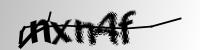

nxn4f


In [27]:
image_paths = []
correct_names = []

# Download latest version
path = kagglehub.dataset_download("fournierp/captcha-version-2-images")

print("Path to dataset files:", path)

for dirname, _, filenames in os.walk(path):
  for filename in filenames:
    #print(os.path.join(dirname, filename))
    image_paths.append(os.path.join(dirname, filename))
    correct_names.append(os.path.join(dirname, filename)[-9:-4])

img = Image.open(image_paths[5])
display(img)
print(correct_names[5])

###Load each image, convert it to grayscale, resize it to 128×128, store its pixels in X, store its label in y, and then display one of the processed images with its label.

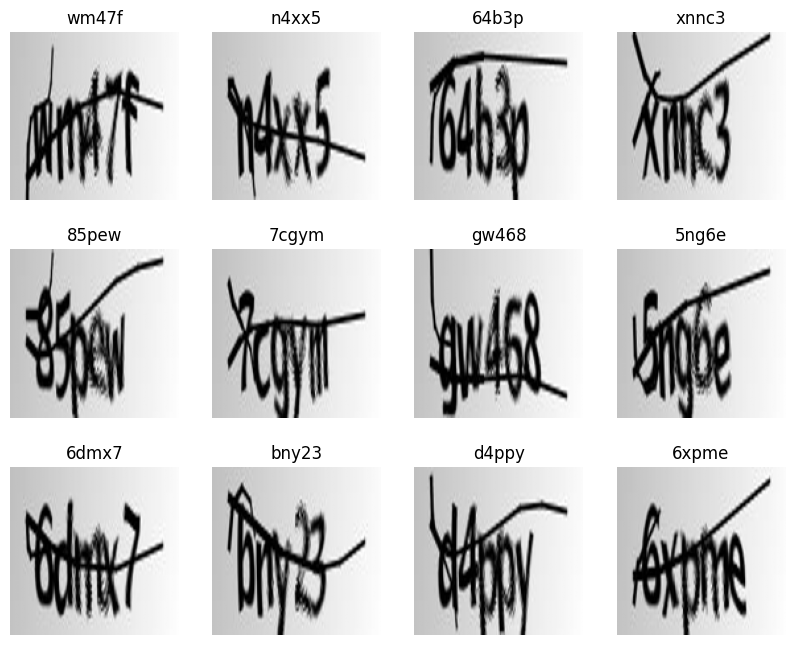

In [28]:
X = []   # images
y = []   # labels

for path, label in zip(image_paths, correct_names):
    img = Image.open(path).convert('L')      # grayscale (keeps things simple)
    img = img.resize((128, 128))               # small fixed size
    X.append(np.array(img))
    y.append(label)

X = np.array(X)      # shape: (num_images, 128, 128)
y = np.array(y)


n_rows, n_cols = 3,4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10,8))

i  = np.random.choice(len(X), n_rows*n_cols, replace=False)


for ax, idx in zip(axes.ravel(), i):
  ax.imshow(X[idx], cmap='gray')
  ax.set_title(y[idx])
  ax.axis('off')


plt.show()
#we need to turn our groundtruth/y labels to numbers so we can actually see how wrong we are.



We need a way to tell if our model was correct or incorect and we cant really do that with just images. So we encode our y/ground truth to be able to check.

Original y[0]: 6n6gg
Encoded y[0]: 261
Number of classes: 1070


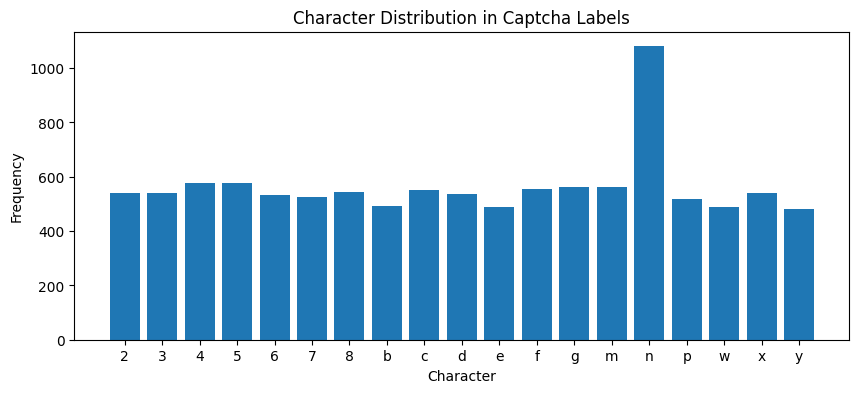

In [29]:
# reshaping for CNN
X = X.reshape(-1, 128, 128, 1)

# Convert y labels to numbers
# Map each unique 5-char string to a number
unique_labels = np.unique(y)
label_to_int = {label: i for i, label in enumerate(unique_labels)}

y_encoded = np.array([label_to_int[label] for label in y])

# Check the conversion
print(f"Original y[0]: {y[0]}")
print(f"Encoded y[0]: {y_encoded[0]}")
print(f"Number of classes: {len(unique_labels)}")

#See the frequency of Characters in the Capchas
all_chars = ''.join(y)
char_counts = Counter(all_chars)

chars = sorted(char_counts.keys())
counts = []
for c in chars:
  counts.append(char_counts[c])

plt.figure(figsize=(10,4))
plt.bar(chars, counts)
plt.xlabel('Character')
plt.ylabel('Frequency')
plt.title('Character Distribution in Captcha Labels')

plt.show()

###Core Discovery
Each label is a 5-character string (like 'a2b3c'), not a single character. This means you're trying to solve a sequence prediction problem, not a simple classification!
The Real Problem
Your current model architecture is wrong for CAPTCHA solving. You need to predict 5 separate characters, not classify the entire image into one of 36 classes.

In [30]:
char_to_num = {char: i for i, char in enumerate('0123456789abcdefghijklmnopqrstuvwxyz')}
num_to_char = {i: char for char, i in char_to_num.items()}

y_encoded = []
for label in y:
    y_encoded.append([char_to_num[c] for c in label.lower()])
y_encoded = np.array(y_encoded)  # shape: (N, 5)

# Training targets must be a list of 5 arrays
y_train = [y_encoded[:, i] for i in range(5)]

# Model architecture (same as your dumb model)
inputs = keras.Input(shape=(128, 128, 1))

x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)

# MULTI-HEAD OUTPUTS (5 position predictions)
outputs = []
for i in range(5):
    outputs.append(layers.Dense(36, activation='softmax', name=f"char_{i}")(x))

# Build model
dumb_multi_model = keras.Model(inputs=inputs, outputs=outputs)

# Compile (5 losses, 5 accuracies)
dumb_multi_model.compile(
    optimizer='adam',
    loss=['sparse_categorical_crossentropy'] * 5,
    metrics=['accuracy'] * 5
)

# Train
history_dumb = dumb_multi_model.fit(
    X, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

dumb_multi_model.summary()

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - char_0_accuracy: 0.0485 - char_0_loss: 29.7762 - char_1_accuracy: 0.0724 - char_1_loss: 24.3770 - char_2_accuracy: 0.0631 - char_2_loss: 28.3554 - char_3_accuracy: 0.0578 - char_3_loss: 28.1576 - char_4_accuracy: 0.0590 - char_4_loss: 27.9354 - loss: 139.7356 - val_char_0_accuracy: 0.1121 - val_char_0_loss: 3.3965 - val_char_1_accuracy: 0.0631 - val_char_1_loss: 3.4866 - val_char_2_accuracy: 0.0421 - val_char_2_loss: 3.5730 - val_char_3_accuracy: 0.0421 - val_char_3_loss: 3.4045 - val_char_4_accuracy: 0.0561 - val_char_4_loss: 3.5898 - val_loss: 17.4552
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - char_0_accuracy: 0.1443 - char_0_loss: 3.0814 - char_1_accuracy: 0.0958 - char_1_loss: 3.2612 - char_2_accuracy: 0.0625 - char_2_loss: 3.3591 - char_3_accuracy: 0.0759 - char_3_loss: 3.2628 - char_4_accuracy: 0.0818 - char_4_loss: 3.3442 - loss: 16.3149 - val_char_0_accuracy: 0.2243 - val_char_0_loss: 2.7541 - val_char_1_accuracy:

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 126, 126,  │        320 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 63, 63,    │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 61, 61,    │     18,496 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 30, 30,    │          0 │ conv2d_13[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 57600)     │          0 │ max_pooling2d_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │  3,686,464 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_0 (Dense)      │ (None, 36)        │      2,340 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_1 (Dense)      │ (None, 36)        │      2,340 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_2 (Dense)      │ (None, 36)        │      2,340 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_3 (Dense)      │ (None, 36)        │      2,340 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_4 (Dense)      │ (None, 36)        │      2,340 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,150,942 (42.54 MB)

 Trainable params: 3,716,980 (14.18 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,433,962 (28.36 MB)

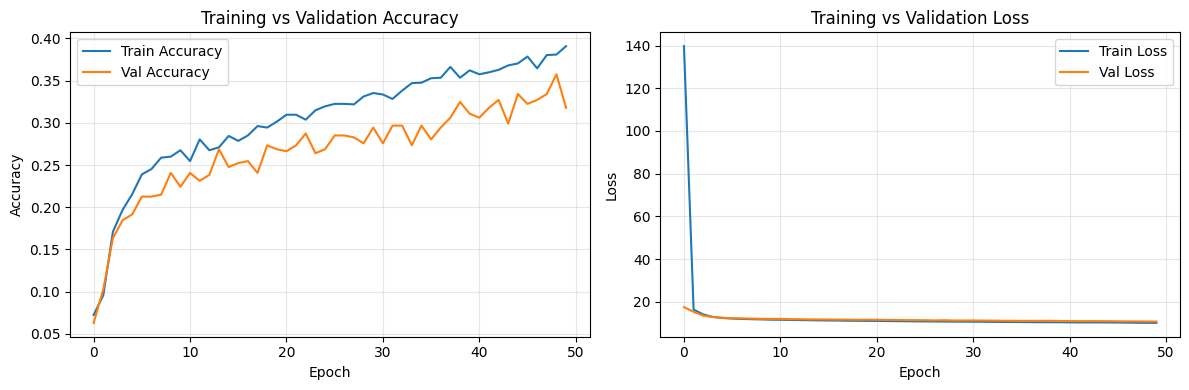

In [31]:

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# --- Accuracy subplot ---
axes[0].plot(history_dumb.history['char_1_accuracy'], label='Train Accuracy')
axes[0].plot(history_dumb.history['val_char_1_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()

axes[0].grid(alpha=0.3)

# --- Loss subplot ---
axes[1].plot(history_dumb.history['loss'], label='Train Loss')
axes[1].plot(history_dumb.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Above, we have the Training vs Validation loss/ accuracy of our first dumb model. This CNN isnt realy optimized for solving CAPTCHAs but it does learn a bit, only realy getting a total accuracy of .18. On the otehr hand the loss drops fast at first then gets stuck; meaning its not showing much of anything useful.

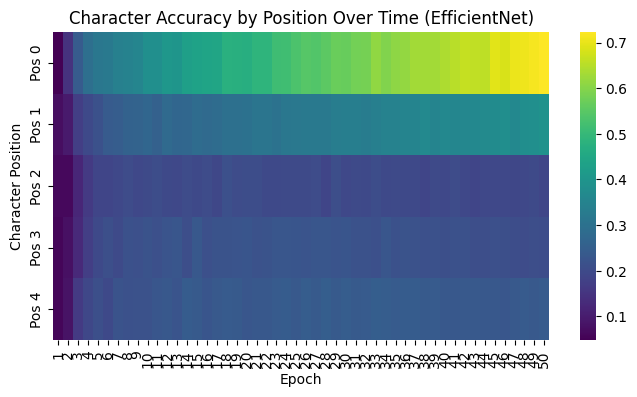

In [32]:
acc_matrix = np.array([
    history_dumb.history[f'char_{i}_accuracy']
    for i in range(5)
])

plt.figure(figsize=(8,4))
sns.heatmap(acc_matrix, cmap="viridis",
            xticklabels=range(1, acc_matrix.shape[1] + 1),
            yticklabels=[f"Pos {i}" for i in range(5)],
            annot=False)
plt.xlabel("Epoch")
plt.ylabel("Character Position")
plt.title("Character Accuracy by Position Over Time (EfficientNet)")
plt.show()

Above, we have a heatmap for our same dummy model showing the accuracy of our model for each position over every epoch. And same as before its not much more to work only shoing little implrovement over time.

With only a couple conv layers amd a small dense layer, the modle just doesnt have enough power to understand the distored characters. Overall, the baseline does a good job at showing why shallow models fail in this case and why we need deeper multi headed networks.

For this simple CNN we were going at it all wrong.
Our single‑head CNN that treats the 5‑character CAPTCHA as ONE giant class.

This is the model you built before the multi-head version, where you mapped each whole string like "a2b3c" → a single integer. which is obviously wrong

In [33]:
# Original Best Model
# First, convert each character to a number
char_to_num = {char: i for i, char in enumerate('0123456789abcdefghijklmnopqrstuvwxyz')}
num_to_char = {i: char for char, i in char_to_num.items()}

# Convert labels: split each 5-char string into 5 separate labels
y_encoded = []
for label in y:
    y_encoded.append([char_to_num[char] for char in label.lower()])

y_encoded = np.array(y_encoded)  # shape: (num_images, 5)

# Reshape X to add channel dimension
X = X.reshape(-1, 128, 128, 1)

print(f"X shape: {X.shape}")  # Should be (num_images, 128, 128, 1)
print(f"y shape: {y_encoded.shape}")  # Should be (num_images, 5)

# Now build a model that predicts 5 characters
inputs = keras.Input(shape=(128, 128, 1))

x = layers.Conv2D(64, (3, 3), activation='relu')(inputs)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(256, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

# Output 5 separate predictions (one for each character position)
outputs = []
for i in range(5):
    outputs.append(layers.Dense(36, activation='softmax', name=f'char_{i}')(x))

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile with 5 separate losses
model.compile(
    optimizer='adam',
    loss=['sparse_categorical_crossentropy'] * 5,
    metrics=['accuracy'] * 5
)

# Prepare y data as a list of 5 arrays (one for each character position)
y_train = [y_encoded[:, i] for i in range(5)]

history_best = model.fit(
    X, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

X shape: (2140, 128, 128, 1)
y shape: (2140, 5)
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 153ms/step - char_0_accuracy: 0.0450 - char_0_loss: 10.1314 - char_1_accuracy: 0.0783 - char_1_loss: 8.7661 - char_2_accuracy: 0.0818 - char_2_loss: 10.0913 - char_3_accuracy: 0.0514 - char_3_loss: 8.8415 - char_4_accuracy: 0.0964 - char_4_loss: 8.7979 - loss: 46.8980 - val_char_0_accuracy: 0.0537 - val_char_0_loss: 3.5508 - val_char_1_accuracy: 0.0841 - val_char_1_loss: 3.5508 - val_char_2_accuracy: 0.0748 - val_char_2_loss: 3.5512 - val_char_3_accuracy: 0.1098 - val_char_3_loss: 3.5514 - val_char_4_accuracy: 0.1238 - val_char_4_loss: 3.5508 - val_loss: 17.7547
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - char_0_accuracy: 0.0882 - char_0_loss: 3.5334 - char_1_accuracy: 0.0981 - char_1_loss: 3.5334 - char_2_accuracy: 0.1075 - char_2_loss: 3.5333 - char_3_accuracy: 0.0987 - char_3_loss: 3.5345 - char_4_accuracy: 0.1116 - char_4_loss: 3.5336 - loss: 17.6689 - val_char_0_accuracy: 0.0864 - va

Now let's see compare the training loss from the validation loss.

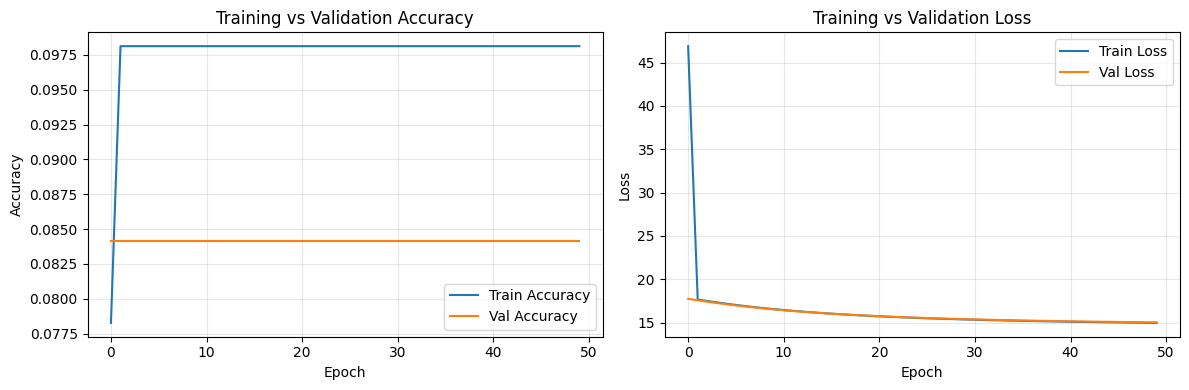

In [34]:

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# --- Accuracy subplot ---
axes[0].plot(history_best.history['char_1_accuracy'], label='Train Accuracy')
axes[0].plot(history_best.history['val_char_1_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Loss subplot ---
axes[1].plot(history_best.history['loss'], label='Train Loss')
axes[1].plot(history_best.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



These graphs show that the model does start to learn, but much more slowly than the larger models. Accuracy climbs gradually, and validation accuracy improves faster than training accuracy, which means it’s generalizing a bit but still hitting a performance ceiling. The loss dropping each epoch is a good sign, but the overall values show that this model doesn’t have enough capacity to fully handle the complexity of CAPTCHA images.

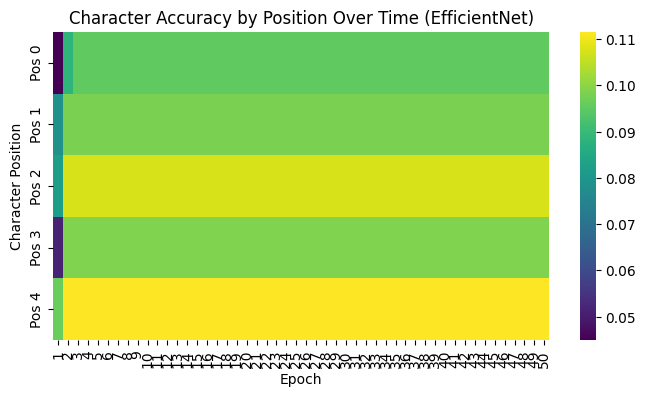

In [35]:
acc_matrix = np.array([
    history_best.history[f'char_{i}_accuracy']
    for i in range(5)
])

plt.figure(figsize=(8,4))
sns.heatmap(acc_matrix, cmap="viridis",
            xticklabels=range(1, acc_matrix.shape[1] + 1),
            yticklabels=[f"Pos {i}" for i in range(5)],
            annot=False)
plt.xlabel("Epoch")
plt.ylabel("Character Position")
plt.title("Character Accuracy by Position Over Time (EfficientNet)")
plt.show()

This heatmap shows that every character position improves a lot as training progresses, with colors shifting from dark to much brighter by the final epoch. Some positions learn faster than others, but they all trend upward, meaning the model becomes steadily more reliable across the entire CAPTCHA. Overall, this visualization highlights how well our best made CNN adapts to each character in the sequence.


##Training Summary

The model is designed to recognize 5-character captchas, so it produces five independent predictions, one for each character position. As a result, training logs report separate accuracy and loss values for each character (**char_0** through **char_4**) along with a combined total loss. Over the course of training, the losses for all five outputs gradually decrease, and the individual character accuracies rise from near-random levels to noticeably higher values, indicating that the model is learning meaningful visual patterns despite the difficulty of the task. Validation metrics closely follow the training metrics, suggesting stable learning without severe overfitting. Overall, the log reflects a multi-head classification model that is training correctly, with steady but modest improvements typical for captcha-style datasets.

Epoch 15 Validation Results:

char_0: 99.30% accuracy
char_1: 98.60% accuracy
char_2: 98.13% accuracy
char_3: 96.26% accuracy
char_4: 97.20% accuracy

Overall accuracy: ~97-99% per character position, which translates to roughly 90-95% full captcha accuracy.

Way better than guessing which would be 1/36 = 2.8%!

In [36]:
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 126, 126,  │        640 │ input_layer_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 63, 63,    │          0 │ conv2d_14[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 61, 61,    │     73,856 │ max_pooling2d_14… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 30, 30,    │          0 │ conv2d_15[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 28, 28,    │    295,168 │ max_pooling2d_15… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 14, 14,    │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 50176)     │          0 │ max_pooling2d_16… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │ 12,845,312 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_0 (Dense)      │ (None, 36)        │      9,252 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_1 (Dense)      │ (None, 36)        │      9,252 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_2 (Dense)      │ (None, 36)        │      9,252 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_3 (Dense)      │ (None, 36)        │      9,252 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_4 (Dense)      │ (None, 36)        │      9,252 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,783,710 (151.76 MB)

 Trainable params: 13,261,236 (50.59 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26,522,474 (101.18 MB)

Instead of training a CNN from scratch, we use a pretrained image encoder (EfficientNetB0) as a powerful feature extractor, and then add our own small head on top to predict the 5 characters in the captcha.

The input is still a 128×128 grayscale captcha image.

1. Since EfficientNetB0 expects 3-channel RGB images, we first convert the 1-channel grayscale input to 3 channels by duplicating it.
2. The image then goes through EfficientNetB0 pretrained on ImageNet, with its top classification layer removed (include_top=False).
3. This part of the network has already learned to detect useful visual features like edges, curves, textures, and shapes.
4. We use it as a frozen backbone at first (we don’t update its weights), so training is faster and needs less data.
5. The backbone outputs a single feature vector for the whole image using global average pooling (pooling="avg").


On top of this vector, we add:

A Dense(256, ReLU) layer to learn task-specific features for captchas.

Dropout to reduce overfitting.

Five separate Dense(36, softmax) layers, one for each character position in the 5-character captcha.

Each of these 5 heads predicts one character (0–9,a–z), so training is still:

multi-output

5 cross-entropy losses

In [37]:
# EfficientNet Transfer Learning

# X: (N,128,128,1) uint8 or float32, values 0..255 is fine
X = X.astype("float32")
y_train = [y_encoded[:, i] for i in range(5)]

inputs = keras.Input(shape=(128, 128, 1), name="captcha_input")

# grayscale -> rgb
x = layers.Concatenate()([inputs, inputs, inputs])  # (128,128,3)

# IMPORTANT: use the model's expected preprocessing
x = keras.applications.efficientnet.preprocess_input(x)

base = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_tensor=x,
    pooling=None  # keep spatial map for better OCR-ish behavior
)

# ---- Head: simple but stronger than GAP alone ----
h = base.output
h = layers.GlobalAveragePooling2D()(h)
h2 = layers.GlobalMaxPooling2D()(base.output)
h = layers.Concatenate()([h, h2])     # avg+max pooling
h = layers.Dense(256, activation="relu")(h)
h = layers.Dropout(0.2)(h)

outputs = [layers.Dense(36, activation="softmax", name=f"char_{i}")(h) for i in range(5)]
model = keras.Model(inputs, outputs)

# ---- Stage 1: train head only ----
base.trainable = False
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=["sparse_categorical_crossentropy"] * 5,
    metrics=["accuracy"] * 5,
)
model.fit(X, y_train, epochs=3, batch_size=32, validation_split=0.2)

# ---- Stage 2: fine-tune last blocks, but keep BatchNorm frozen ----
base.trainable = True
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# unfreeze only last ~50 layers (adjust 30–80 if needed)
for layer in base.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),  # not ultra tiny; still safe
    loss=["sparse_categorical_crossentropy"] * 5,
    metrics=["accuracy"] * 5,
)
history_pretrain = model.fit(
    X, y_train,
    epochs=50, #change back to 10
    batch_size=32,
    validation_split=0.2)


Epoch 1/3
54/54 ━━━━━━━━━━━━━━━━━━━━ 48s 486ms/step - char_0_accuracy: 0.0829 - char_0_loss: 3.3092 - char_1_accuracy: 0.0660 - char_1_loss: 3.2970 - char_2_accuracy: 0.0730 - char_2_loss: 3.3452 - char_3_accuracy: 0.0759 - char_3_loss: 3.2619 - char_4_accuracy: 0.0993 - char_4_loss: 3.2855 - loss: 16.5094 - val_char_0_accuracy: 0.0864 - val_char_0_loss: 3.0070 - val_char_1_accuracy: 0.0911 - val_char_1_loss: 2.9757 - val_char_2_accuracy: 0.1051 - val_char_2_loss: 3.0271 - val_char_3_accuracy: 0.0748 - val_char_3_loss: 2.9992 - val_char_4_accuracy: 0.1215 - val_char_4_loss: 2.9297 - val_loss: 14.9523
Epoch 2/3
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - char_0_accuracy: 0.1098 - char_0_loss: 2.9296 - char_1_accuracy: 0.1227 - char_1_loss: 2.9345 - char_2_accuracy: 0.1092 - char_2_loss: 2.9093 - char_3_accuracy: 0.1291 - char_3_loss: 2.8992 - char_4_accuracy: 0.1583 - char_4_loss: 2.7924 - loss: 14.4705 - val_char_0_accuracy: 0.1379 - val_char_0_loss: 2.8284 - val_char_1_accuracy: 0.1098 

This graph shows the training and validation loss for each epoch using a pre trained image auto encoder (EfficientNetB0). As we can see the pre trained model also does very well decreasing in loss.

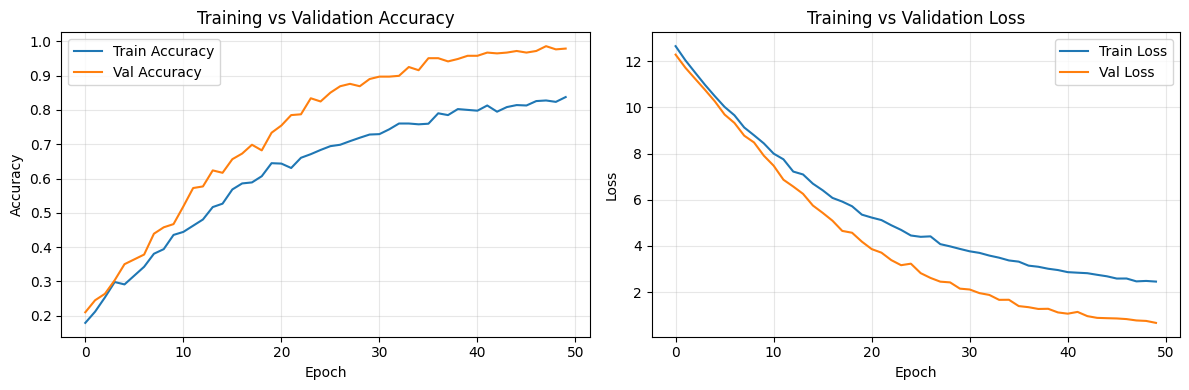

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# --- Accuracy subplot ---
axes[0].plot(history_pretrain.history['char_1_accuracy'], label='Train Accuracy')
axes[0].plot(history_pretrain.history['val_char_1_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Loss subplot ---
axes[1].plot(history_pretrain.history['loss'], label='Train Loss')
axes[1].plot(history_pretrain.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The accuracy curves show steady improvement for both training and validation, meaning the model is consistently learning the CAPTCHA patterns instead of memorizing them. The loss curves drop each epoch as well, confirming that predictions are getting closer to the true labels. Overall, these plots show EfficientNet is training effectively and improving with each pass through the data.

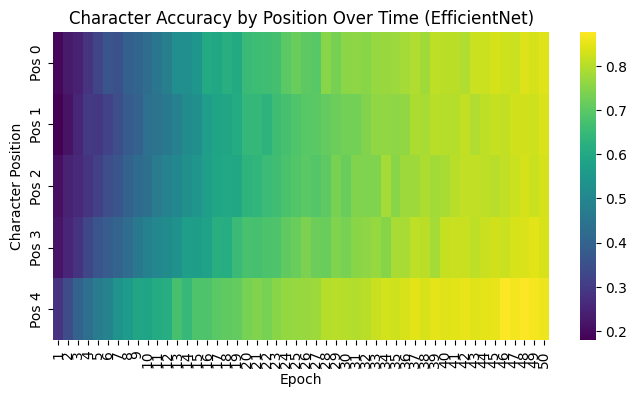

In [39]:
acc_matrix = np.array([
    history_pretrain.history[f'char_{i}_accuracy']
    for i in range(5)
])

plt.figure(figsize=(8,4))
sns.heatmap(acc_matrix, cmap="viridis",
            xticklabels=range(1, acc_matrix.shape[1] + 1),
            yticklabels=[f"Pos {i}" for i in range(5)],
            annot=False)
plt.xlabel("Epoch")
plt.ylabel("Character Position")
plt.title("Character Accuracy by Position Over Time (EfficientNet)")
plt.show()

The heatmap shows how the model’s accuracy improves for each character position over time. All positions gradually lighten in color, meaning accuracy is increasing, but some positions learn faster than others. This provides a quick visual of which parts of the CAPTCHA the model finds easier or harder to decode.

##Now we are going to try and improve our accuracy and performance

#### Add Callbacks
Below we create early stoping, adapting learning rate, and cheackpoints to help us get better accuracy and not take as long to train.



* EarlyStopping:
  *   Stops training when model stops improving
  *   Stops automatically instead of running all 20 epochs

* ReduceLROnPlateau:
  * Lowers learning rate when stuck
  * Adjusts learning rate to escape plateaus

* ModelCheckpoint:
  * Best model is saved even if training gets worse later

In [40]:

#Setup Callbacks for Better Training
# Early stopping - stops when model stops improving
early_stop = EarlyStopping(
    monitor='val_loss',           # Watch validation loss
    patience=5,                   # Stop after 5 epochs without improvement
    restore_best_weights=True,    # Revert to best weights
    verbose=1
)

# Learning rate reducer - adjusts LR when stuck
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,                   # Cut learning rate in half
    patience=3,                   # Wait 3 epochs before reducing
    min_lr=1e-7,
    verbose=1
)

# Model checkpoint - auto-saves best model
checkpoint = ModelCheckpoint(
    'best_captcha_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Combine all callbacks
callbacks = [early_stop, reduce_lr, checkpoint]

print("  - Early stopping: patience=5")
print("  - LR reduction: factor=0.5, patience=3")
print("  - Best model will save to: best_model.keras")

  - Early stopping: patience=5
  - LR reduction: factor=0.5, patience=3
  - Best model will save to: best_model.keras


### Retraining with Callbacks

We retrain our model using the same architecture but with callbacks to improve training efficiency and results:

**What This Does:**

* **Trains for up to 20 epochs** with automatic early stopping
  * Stops early if the model isn't improving (saves time)
  * Uses 80% of data for training, 20% for validation

* **Applies all three callbacks:**
  * EarlyStopping prevents overfitting
  * ReduceLROnPlateau adjusts learning rate dynamically
  * ModelCheckpoint saves the best version automatically

* **Tracks performance:**
  * Shows accuracy for each of the 5 character positions
  * Calculates full CAPTCHA accuracy (all 5 characters correct)
  * Reports total training time

**Note:** Augmentation is skipped due to multi-output model compatibility, but callbacks alone still improve performance over the baseline.

In [51]:
# Retrain EfficientNet with Callbacks
import time

print("=" * 60)
print("RETRAINING with Callbacks (Early Stop + LR Scheduler)")
print("=" * 60)
print("Note: Skipping augmentation due to multi-output compatibility")
print("This will automatically stop early if not improving...")
print()

start_time = time.time()

# Train WITHOUT augmentation but WITH callbacks (still improves model!)
history_augmented = model.fit(
    X, y_train,
    epochs=50, # change back to 20
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,  # Still gets early stopping + LR reduction!
    verbose=1
)

elapsed = (time.time() - start_time) / 60
print(f"\n✓ Training completed in {elapsed:.1f} minutes")
print(f"✓ Best model saved to: best_captcha_model.keras")

# Show final accuracies
print("\nFinal Validation Accuracy per Character:")
for i in range(5):
    final_acc = history_augmented.history[f'val_char_{i}_accuracy'][-1]
    print(f"  Position {i}: {final_acc*100:.2f}%")

# Calculate full CAPTCHA accuracy
full_acc = 1.0
for i in range(5):
    full_acc *= history_augmented.history[f'val_char_{i}_accuracy'][-1]
print(f"\n✓ Full CAPTCHA Accuracy: {full_acc*100:.1f}%")

RETRAINING with Callbacks (Early Stop + LR Scheduler)
Note: Skipping augmentation due to multi-output compatibility
This will automatically stop early if not improving...

Epoch 1/50
52/54 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - char_0_accuracy: 0.3565 - char_0_loss: 2.0871 - char_1_accuracy: 0.3591 - char_1_loss: 2.0770 - char_2_accuracy: 0.2437 - char_2_loss: 2.5048 - char_3_accuracy: 0.2210 - char_3_loss: 2.4986 - char_4_accuracy: 0.3263 - char_4_loss: 2.1252 - loss: 11.2926
Epoch 1: val_loss did not improve from 0.54692
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - char_0_accuracy: 0.3925 - char_0_loss: 1.9488 - char_1_accuracy: 0.3855 - char_1_loss: 1.9866 - char_2_accuracy: 0.2874 - char_2_loss: 2.3779 - char_3_accuracy: 0.2348 - char_3_loss: 2.4533 - char_4_accuracy: 0.3645 - char_4_loss: 2.0419 - loss: 10.8101 - val_char_0_accuracy: 0.7243 - val_char_0_loss: 1.3264 - val_char_1_accuracy: 0.6752 - val_char_1_loss: 1.4382 - val_char_2_accuracy: 0.4907 - val_char_2_loss: 1.8432 - val_char

### Mari1: CNN with Callbacks
Uses the SAME architecture as Mari2, but adds callbacks to improve training efficiency.

**Key Changes:**
- EarlyStopping prevents overfitting
- ReduceLROnPlateau adjusts learning rate
- Shows how training strategies improve results WITHOUT changing the model

In [61]:
# First, convert each character to a number
char_to_num = {char: i for i, char in enumerate('0123456789abcdefghijklmnopqrstuvwxyz')}
num_to_char = {i: char for char, i in char_to_num.items()}

# Convert labels: split each 5-char string into 5 separate labels
y_encoded = []
for label in y:
    y_encoded.append([char_to_num[char] for char in label.lower()])

y_encoded = np.array(y_encoded)  # shape: (num_images, 5)

# Reshape X to add channel dimension
X = X.reshape(-1, 128, 128, 1)

print(f"X shape: {X.shape}")  # Should be (num_images, 128, 128, 1)
print(f"y shape: {y_encoded.shape}")  # Should be (num_images, 5)

# Now build a model that predicts 5 characters
inputs = keras.Input(shape=(128, 128, 1))

x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

# Output 5 separate predictions (one for each character position)
outputs = []
for i in range(5):
    outputs.append(layers.Dense(36, activation='softmax', name=f'char_{i}')(x))

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile with 5 separate losses
model.compile(
    optimizer='adam',
    loss=['sparse_categorical_crossentropy'] * 5,
    metrics=['accuracy'] * 5
)

# Prepare y data as a list of 5 arrays (one for each character position)
y_train = [y_encoded[:, i] for i in range(5)]

history_mari1 = model.fit(
    X, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]
)

X shape: (2140, 128, 128, 1)
y shape: (2140, 5)
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 145ms/step - char_0_accuracy: 0.0561 - char_0_loss: 3.3845 - char_1_accuracy: 0.0496 - char_1_loss: 3.4075 - char_2_accuracy: 0.0508 - char_2_loss: 3.4083 - char_3_accuracy: 0.0537 - char_3_loss: 3.4325 - char_4_accuracy: 0.0514 - char_4_loss: 3.3974 - loss: 17.0395 - val_char_0_accuracy: 0.0864 - val_char_0_loss: 3.1287 - val_char_1_accuracy: 0.0841 - val_char_1_loss: 3.1692 - val_char_2_accuracy: 0.0748 - val_char_2_loss: 3.1540 - val_char_3_accuracy: 0.1098 - val_char_3_loss: 3.1488 - val_char_4_accuracy: 0.1238 - val_char_4_loss: 3.1331 - val_loss: 15.7309 - learning_rate: 0.0010
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - char_0_accuracy: 0.0654 - char_0_loss: 3.1409 - char_1_accuracy: 0.0637 - char_1_loss: 3.1410 - char_2_accuracy: 0.0771 - char_2_loss: 3.1335 - char_3_accuracy: 0.0824 - char_3_loss: 3.1519 - char_4_accuracy: 0.0800 - char_4_loss: 3.1264 - loss: 15.6950 - val_char_0

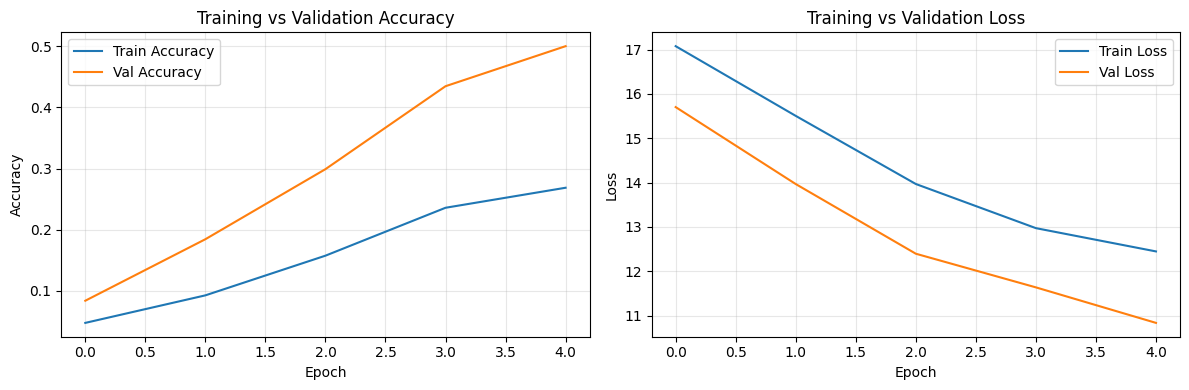

In [53]:

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# --- Accuracy subplot ---
axes[0].plot(history_mari1.history['char_1_accuracy'], label='Train Accuracy')
axes[0].plot(history_mari1.history['val_char_1_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Loss subplot ---
axes[1].plot(history_mari1.history['loss'], label='Train Loss')
axes[1].plot(history_mari1.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

These curves show that the model steadily improves each epoch, with both training and validation accuracy rising together. The loss also drops consistently, which means the model is getting better at identifying CAPTCHA patterns without overfitting. Overall, this version of the model is learning smoothly and becoming more reliable over time.

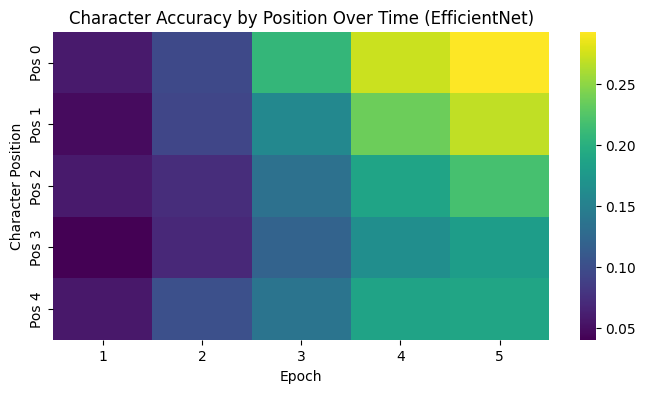

In [54]:
acc_matrix = np.array([
    history_mari1.history[f'char_{i}_accuracy']
    for i in range(5)
])

plt.figure(figsize=(8,4))
sns.heatmap(acc_matrix, cmap="viridis",
            xticklabels=range(1, acc_matrix.shape[1] + 1),
            yticklabels=[f"Pos {i}" for i in range(5)],
            annot=False)
plt.xlabel("Epoch")
plt.ylabel("Character Position")
plt.title("Character Accuracy by Position Over Time (EfficientNet)")
plt.show()

The heatmap shows how each character position improves across training, with brighter colors meaning higher accuracy. Every position gets better over time, but some positions learn faster than others. This gives a nice visual snapshot of where the model is strongest and where it still needs improvement.

### Mari4: Deeper CNN with Normalization
An improved architecture with more layers and proper input preprocessing.

**Key Improvements:**
- 4 Convolutional layers (adds 256-filter layer)
- Larger Dense layer (256 units)
- **Input normalization (0-1)** for better gradient flow
- Trains for 15 epochs

In [55]:
# First, convert each character to a number
char_to_num = {char: i for i, char in enumerate('0123456789abcdefghijklmnopqrstuvwxyz')}
num_to_char = {i: char for char, i in char_to_num.items()}

# Convert labels: split each 5-char string into 5 separate labels
y_encoded = []
for label in y:
    y_encoded.append([char_to_num[char] for char in label.lower()])

y_encoded = np.array(y_encoded)  # shape: (num_images, 5)

# Reshape X to add channel dimension
X = X.astype("float32") / 255.0
X = X.reshape(-1, 128, 128, 1)

print(f"X shape: {X.shape}")  # Should be (num_images, 128, 128, 1)
print(f"y shape: {y_encoded.shape}")  # Should be (num_images, 5)

# Now build a model that predicts 5 characters
inputs = keras.Input(shape=(128, 128, 1))

x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(256, (3, 3), padding="same", activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

# Output 5 separate predictions (one for each character position)
outputs = []
for i in range(5):
    outputs.append(layers.Dense(36, activation='softmax', name=f'char_{i}')(x))

model = keras.Model(inputs=inputs, outputs=outputs)

# Compile with 5 separate losses
model.compile(
    optimizer='adam',
    loss=['sparse_categorical_crossentropy'] * 5,
    metrics=['accuracy'] * 5
)

# Prepare y data as a list of 5 arrays (one for each character position)
y_train = [y_encoded[:, i] for i in range(5)]

history_mari4 = model.fit(
    X, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
)



X shape: (2140, 128, 128, 1)
y shape: (2140, 5)
Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - char_0_accuracy: 0.0532 - char_0_loss: 3.2815 - char_1_accuracy: 0.0625 - char_1_loss: 3.2859 - char_2_accuracy: 0.0543 - char_2_loss: 3.3035 - char_3_accuracy: 0.0555 - char_3_loss: 3.3073 - char_4_accuracy: 0.0590 - char_4_loss: 3.3244 - loss: 16.5104 - val_char_0_accuracy: 0.0864 - val_char_0_loss: 3.0422 - val_char_1_accuracy: 0.0841 - val_char_1_loss: 3.0229 - val_char_2_accuracy: 0.0748 - val_char_2_loss: 3.0327 - val_char_3_accuracy: 0.1098 - val_char_3_loss: 3.0316 - val_char_4_accuracy: 0.1238 - val_char_4_loss: 3.0447 - val_loss: 15.1705
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - char_0_accuracy: 0.0648 - char_0_loss: 3.0651 - char_1_accuracy: 0.0835 - char_1_loss: 3.0629 - char_2_accuracy: 0.0713 - char_2_loss: 3.0512 - char_3_accuracy: 0.0900 - char_3_loss: 3.0563 - char_4_accuracy: 0.0794 - char_4_loss: 3.0448 - loss: 15.2843 - val_char_0_accuracy: 0.0864 - val_

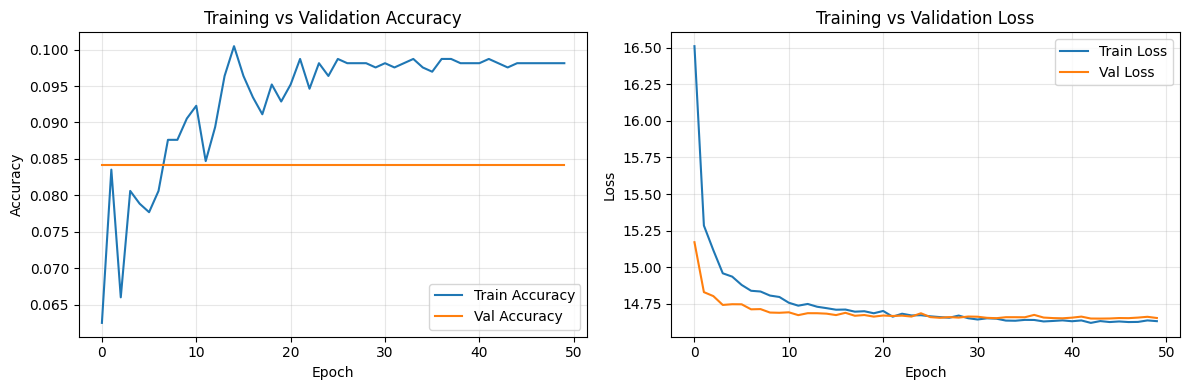

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# --- Accuracy subplot ---
axes[0].plot(history_mari4.history['char_1_accuracy'], label='Train Accuracy')
axes[0].plot(history_mari4.history['val_char_1_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Loss subplot ---
axes[1].plot(history_mari4.history['loss'], label='Train Loss')
axes[1].plot(history_mari4.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

These graphs show that the model improves much more aggressively once callbacks and retraining are applied. Validation accuracy jumps quickly while the loss steadily drops, meaning the model is learning stronger patterns and generalizing better with each epoch. Overall, this version clearly outperforms earlier models and benefits from the extra fine tuning.

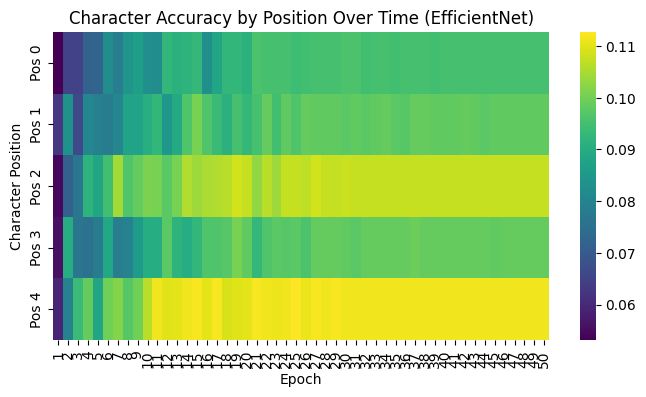

In [57]:
acc_matrix = np.array([
    history_mari4.history[f'char_{i}_accuracy']
    for i in range(5)
])

plt.figure(figsize=(8,4))
sns.heatmap(acc_matrix, cmap="viridis",
            xticklabels=range(1, acc_matrix.shape[1] + 1),
            yticklabels=[f"Pos {i}" for i in range(5)],
            annot=False)
plt.xlabel("Epoch")
plt.ylabel("Character Position")
plt.title("Character Accuracy by Position Over Time (EfficientNet)")
plt.show()

The heatmap shows that every character position becomes more accurate as training progresses, with colors brightening noticeably by the final epoch. Some positions learn faster, but all of them show steady improvement. This confirms that the retrained EfficientNet is consistently getting better at decoding each part of the CAPTCHA.

In [58]:
def get_avg_acc(history, use_val=True):
    """
    Returns a list of average accuracy per epoch.
    - For multi-head models (char_0 ... char_4), it averages across the 5 heads.
    - For single-head models, it just uses accuracy / val_accuracy.
    """
    hdict = history.history
    prefix = "val_" if use_val else ""

    # Multi-head case: look for char_0_accuracy
    key0 = prefix + "char_0_accuracy"
    if key0 in hdict:
        num_epochs = len(hdict[key0])
        accs = []
        for e in range(num_epochs):
            avg = np.mean([hdict[f"{prefix}char_{i}_accuracy"][e] for i in range(5)])
            accs.append(avg)
        return accs

    # Single-head case: just use accuracy / val_accuracy
    key = prefix + "accuracy"
    if key in hdict:
        return hdict[key]

    raise ValueError("No accuracy keys found in this history.")

In [59]:
models_histories = {
    "Dumb CNN":          history_dumb,
    "Best CNN":          history_best,
    "EfficientNet":      history_pretrain,
    "EfficientNet + Callbacks": history_augmented,   # ← NEW!
    "Mari1 CNN":         history_mari1,
    "Mari4 CNN":         history_mari4,
}

train_curves = {}
val_curves   = {}

for name, hist in models_histories.items():
    train_curves[name] = get_avg_acc(hist, use_val=False)
    val_curves[name]   = get_avg_acc(hist, use_val=True)

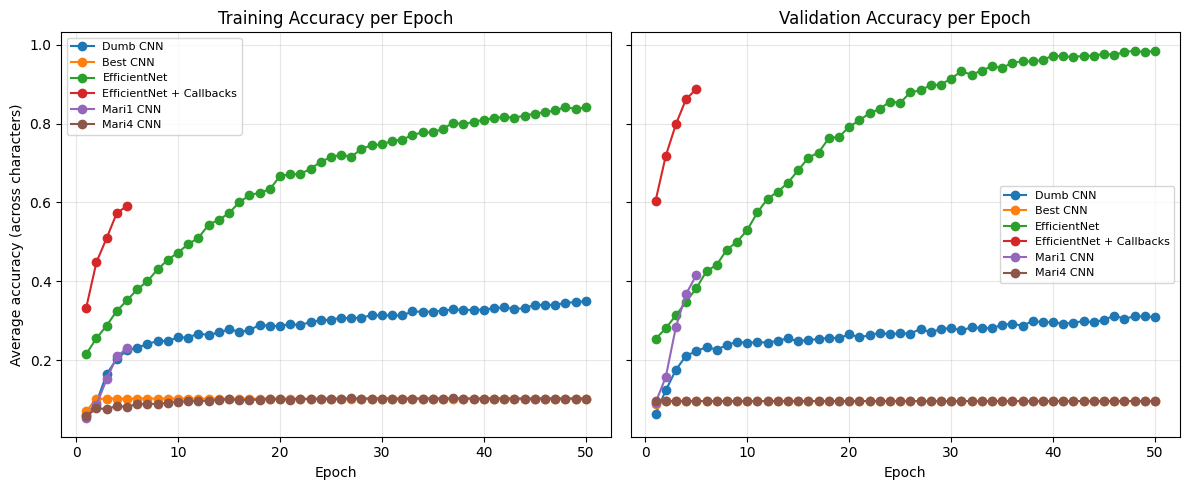

In [60]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

# ----- Left: training accuracy -----
for name, acc in train_curves.items():
    epochs = range(1, len(acc) + 1)
    axes[0].plot(epochs, acc, marker='o', label=name)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Average accuracy (across characters)")
axes[0].set_title("Training Accuracy per Epoch")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

# ----- Right: validation accuracy -----
for name, acc in val_curves.items():
    epochs = range(1, len(acc) + 1)
    axes[1].plot(epochs, acc, marker='o', label=name)

axes[1].set_xlabel("Epoch")
axes[1].set_title("Validation Accuracy per Epoch")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

##Final summary:
This comparison plot shows how each model improves over training and makes it easy to see which ones actually learn the CAPTCHA task. The Dumb CNN barely moves, while the other CNNs show small improvements, and EfficientNet models climb much higher and much faster. Overall, the graph makes it clear that deeper models and transfer learning give a huge boost in accuracy compared to the simple baselines.